In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. CSV 파일 불러오기
# 'tsla_stock.csv' 부분에 실제 다운로드받은 파일명을 적어주세요.
# index_col='Date'는 'Date'(날짜) 컬럼을 데이터의 기준 축으로 쓰겠다는 의미입니다.
tsla = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/TSLA.csv', index_col='Date', parse_dates=True)

# 2. 데이터 확인 (책의 print(samsung)과 동일)
print(tsla)

                   Open         High         Low        Close    Adj Close  \
Date                                                                         
2010-06-29     3.800000     5.000000    3.508000     4.778000     4.778000   
2010-06-30     5.158000     6.084000    4.660000     4.766000     4.766000   
2010-07-01     5.000000     5.184000    4.054000     4.392000     4.392000   
2010-07-02     4.600000     4.620000    3.742000     3.840000     3.840000   
2010-07-06     4.000000     4.000000    3.166000     3.222000     3.222000   
...                 ...          ...         ...          ...          ...   
2022-03-18   874.489990   907.849976  867.390015   905.390015   905.390015   
2022-03-21   914.979980   942.849976  907.090027   921.159973   921.159973   
2022-03-22   930.000000   997.859985  921.750000   993.979980   993.979980   
2022-03-23   979.940002  1040.699951  976.400024   999.109985   999.109985   
2022-03-24  1009.729980  1024.489990  988.799988  1013.919983  1

In [4]:
tsla.shape

(2956, 6)

In [5]:
openValues = tsla[['Open']]

In [6]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range = (0,1))
scaled = scaler.fit_transform(openValues)

In [34]:
TEST_SIZE = 2400
train_data = scaled[:-TEST_SIZE]
test_data = scaled[-TEST_SIZE:]

In [35]:
def make_sample(data, window):
  train = []
  target = []
  for i in range(len(data)-window):
    train.append(data[i:i+window])
    target.append(data[i+window])
  return np.array(train), np.array(target)

X_train, y_train = make_sample(train_data, 30)

In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN  # 👈 SimpleRNN으로 변경

model = Sequential()

# model.add(LSTM(...)) 대신 SimpleRNN을 추가합니다.
model.add(SimpleRNN(16,
                    input_shape=(X_train.shape[1], 1),
                    activation='tanh',
                    return_sequences=False))

model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [37]:
model.compile(optimizer = 'adam', loss='mean_squared_error')
model.fit(X_train, y_train, epochs=100, batch_size = 16)

Epoch 1/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 3.8905e-05
Epoch 2/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 9.5453e-07
Epoch 3/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.1636e-07
Epoch 4/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.0348e-07
Epoch 5/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.0870e-07
Epoch 6/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.0470e-07
Epoch 7/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.9302e-07
Epoch 8/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.8054e-07
Epoch 9/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.7857e-07
Epoch 10/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.7404e-07
Epoch 11/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.7924e-07
Epoch 12/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.6730e-07
Epoch 13/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.7227e-07
Epoch 14/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.7705e-07
Epoch 15/100
33

In [38]:
X_test, y_test=make_sample(test_data,30)
pred=model.predict(X_test)

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


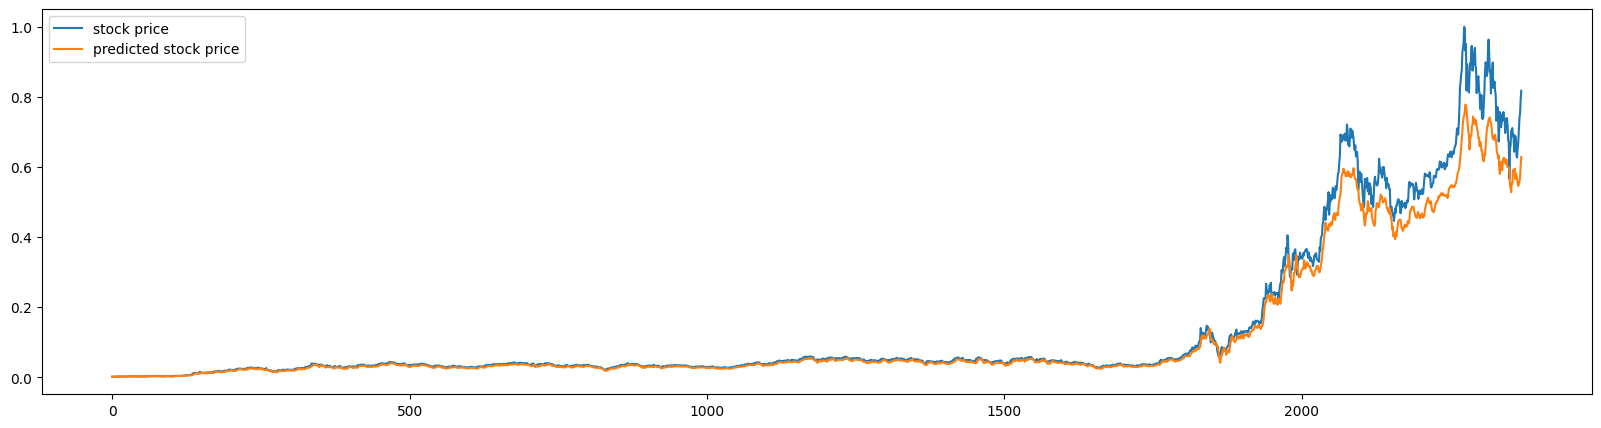

In [61]:
import matplotlib.pyplot as plt
plt.figure(figsize=(20,5))
plt.plot(y_test, label='stock price')
plt.plot(pred, label='predicted stock price')
plt.legend()
plt.show()

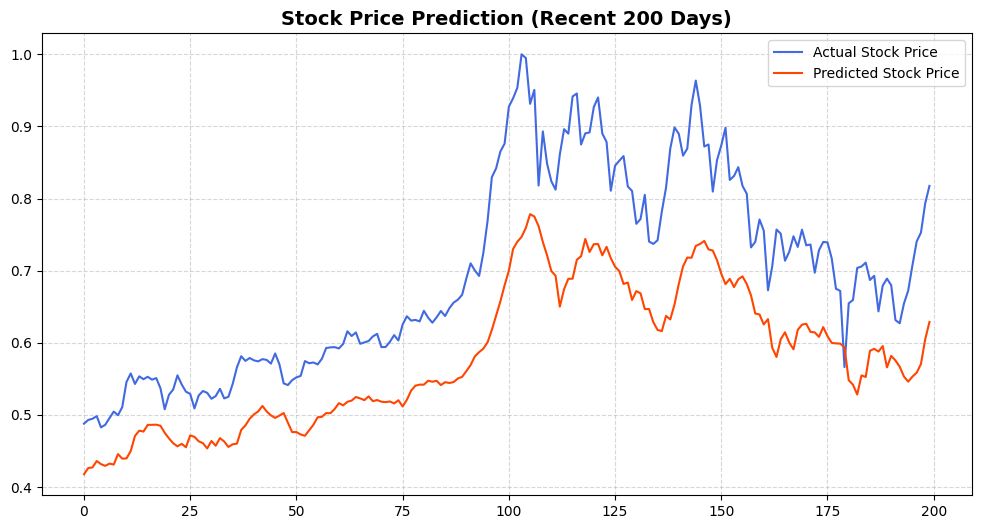

In [58]:
show_days = 200

plt.figure(figsize=(12, 6))
# 뒤에서부터 show_days 만큼 잘라서 그리기
plt.plot(y_test[-show_days:], label='Actual Stock Price', color='royalblue')
plt.plot(pred[-show_days:], label='Predicted Stock Price', color='orangered')

plt.title(f'Stock Price Prediction (Recent {show_days} Days)', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()